# 3.1

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# 1. Load TRAINING data
# ============================================================

train = loadmat("HW09_Problem3.mat")

X = train['q_values'].T          # (512,3)
y = train['outputs'].flatten()   # (512,)

M = len(y)

# ============================================================
# 2. Correlation kernel parameters
# ============================================================

theta = np.array([0.5, 0.3, 0.3])
gamma = 1.5

# ============================================================
# 3. Build correlation matrix R
# ============================================================

diff = np.abs(X[:,None,:] - X[None,:,:])
weighted_dist = np.sum(theta * diff**gamma, axis=2)

R = np.exp(-weighted_dist)

print("Condition number:", np.linalg.cond(R))


# ============================================================
# 4. Estimate Kriging parameters
# ============================================================

ones = np.ones(M)

Rinv_y = np.linalg.solve(R, y)
Rinv_1 = np.linalg.solve(R, ones)

beta0 = (ones @ Rinv_y) / (ones @ Rinv_1)

y_resid = y - beta0*ones
Rinv_resid = np.linalg.solve(R, y_resid)

s2 = (y_resid @ Rinv_resid) / M

print("="*50)
print("Kriging parameters")
print("beta0 =", beta0)
print("s² =", s2)
print("s =", np.sqrt(s2))
print("="*50)



Condition number: 51613.384804627734
Kriging parameters
beta0 = 0.09606407574540783
s² = 444.1317932581245
s = 21.07443458928672


# 3.2

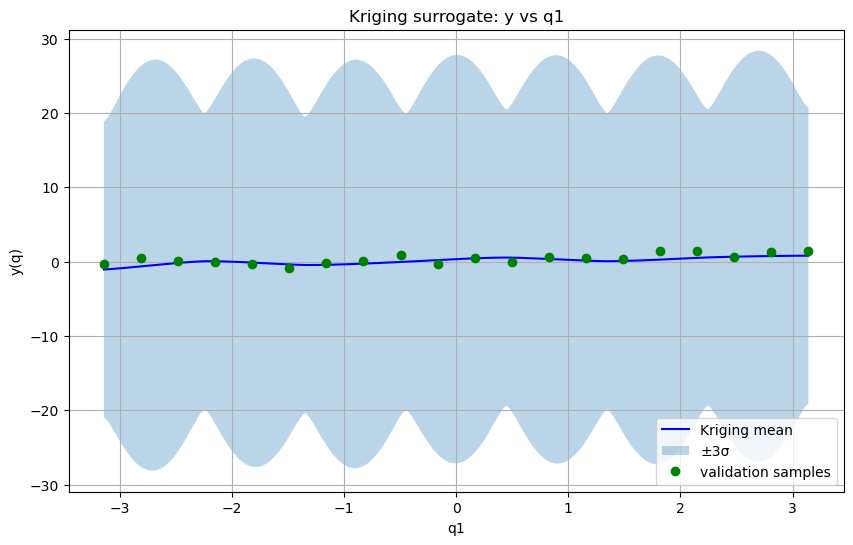

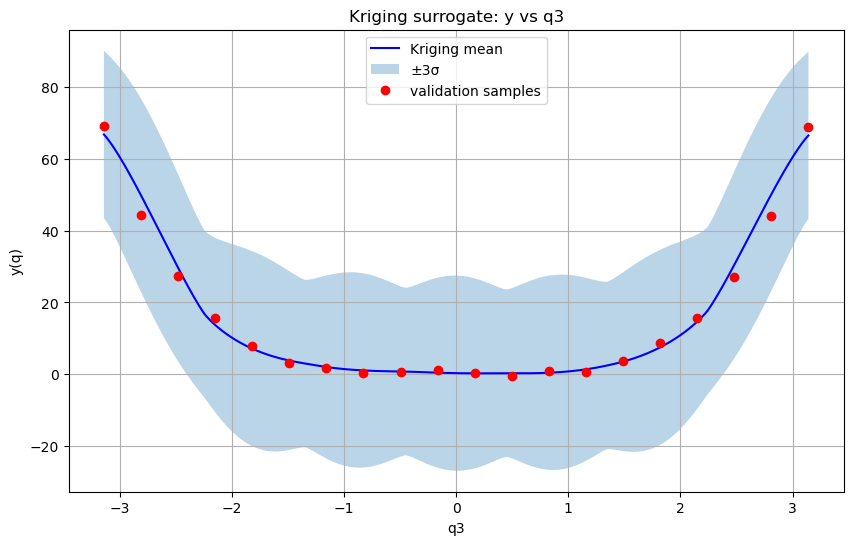


Coverage statistics
-------------------
Q1 slice: 20/20 within 3σ
Q3 slice: 20/20 within 3σ


In [21]:
# ============================================================
# 5. Kriging prediction function
# ============================================================
def kriging_predict(X_star):

    N = X_star.shape[0]

    means = np.zeros(N)
    varsi = np.zeros(N)

    # Precompute quantities
    Rinv = np.linalg.inv(R)
    ones = np.ones(M)

    alpha = Rinv @ (y - beta0 * ones)

    denom = ones @ Rinv @ ones

    for i in range(N):

        diff = np.abs(X - X_star[i])
        r = np.exp(-np.sum(theta * diff**gamma, axis=1))

        # Mean
        mean = beta0 + r @ alpha

        # Variance terms
        v = Rinv @ r

        num = 1 - ones @ v

        var = s2 * (1 - r @ v + (num**2) / denom)

        means[i] = mean
        varsi[i] = max(var, 0)

    return means, varsi


# ============================================================
# 6. Load VERIFICATION datasets
# ============================================================

# q1 slice
val_q1 = loadmat("HW09_Problem3_Q1_Only.mat")

X_val_q1 = val_q1['q_values'].T
y_val_q1 = val_q1['outputs'].flatten()

# q3 slice
val_q3 = loadmat("HW09_Problem3_Q3_Only.mat")

X_val_q3 = val_q3['q_values'].T
y_val_q3 = val_q3['outputs'].flatten()

# ============================================================
# 7. Plot y vs q1
# ============================================================

# Smooth grid for surrogate
q1_grid = np.linspace(-np.pi, np.pi, 2000)

X_grid_q1 = np.column_stack([
    q1_grid,
    np.full_like(q1_grid, -np.pi/4),
    np.full_like(q1_grid, np.pi/4)
])

mean_q1, var_q1 = kriging_predict(X_grid_q1)
std_q1 = np.sqrt(var_q1)

plt.figure(figsize=(10,6))

# Mean curve
plt.plot(q1_grid, mean_q1, 'b', label="Kriging mean")

# Uncertainty band
plt.fill_between(
    q1_grid,
    mean_q1 - 3*std_q1,
    mean_q1 + 3*std_q1,
    alpha=0.3,
    label="±3σ"
)

# Independent validation samples
plt.plot(X_val_q1[:,0], y_val_q1, 'go', label="validation samples")

plt.xlabel("q1")
plt.ylabel("y(q)")
plt.title("Kriging surrogate: y vs q1")
plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# 8. Plot y vs q3
# ============================================================

q3_grid = np.linspace(-np.pi, np.pi, 2000)

X_grid_q3 = np.column_stack([
    np.full_like(q3_grid, np.pi/4),
    np.full_like(q3_grid, -np.pi/4),
    q3_grid
])

mean_q3, var_q3 = kriging_predict(X_grid_q3)
std_q3 = np.sqrt(var_q3)

plt.figure(figsize=(10,6))

plt.plot(q3_grid, mean_q3, 'b', label="Kriging mean")

plt.fill_between(
    q3_grid,
    mean_q3 - 3*std_q3,
    mean_q3 + 3*std_q3,
    alpha=0.3,
    label="±3σ"
)

plt.plot(X_val_q3[:,2], y_val_q3, 'ro', label="validation samples")

plt.xlabel("q3")
plt.ylabel("y(q)")
plt.title("Kriging surrogate: y vs q3")
plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 9. Coverage statistics
# ============================================================

mean_q1_all,var_q1_all = kriging_predict(X_val_q1)
std_q1_all = np.sqrt(var_q1_all)

within_q1 = np.sum(np.abs(y_val_q1-mean_q1_all)<=3*std_q1_all)

mean_q3_all,var_q3_all = kriging_predict(X_val_q3)
std_q3_all = np.sqrt(var_q3_all)

within_q3 = np.sum(np.abs(y_val_q3-mean_q3_all)<=3*std_q3_all)

print()
print("Coverage statistics")
print("-------------------")
print(f"Q1 slice: {within_q1}/{len(y_val_q1)} within 3σ")
print(f"Q3 slice: {within_q3}/{len(y_val_q3)} within 3σ")


In [22]:
# Predict at training points
mean_train, var_train = kriging_predict(X)

print("\nVariance at training points:")
print(f"Maximum variance: {np.max(var_train):.2e}")
print(f"Minimum variance: {np.min(var_train):.2e}")
print(f"Mean variance: {np.mean(var_train):.2e}")
print(f"Number of points with var > 1e-10: {np.sum(var_train > 1e-10)}")

# Should be essentially zero (1e-12 or less typically)


Variance at training points:
Maximum variance: 2.50e-11
Minimum variance: 0.00e+00
Mean variance: 2.78e-12
Number of points with var > 1e-10: 0


## additional analysis for verification

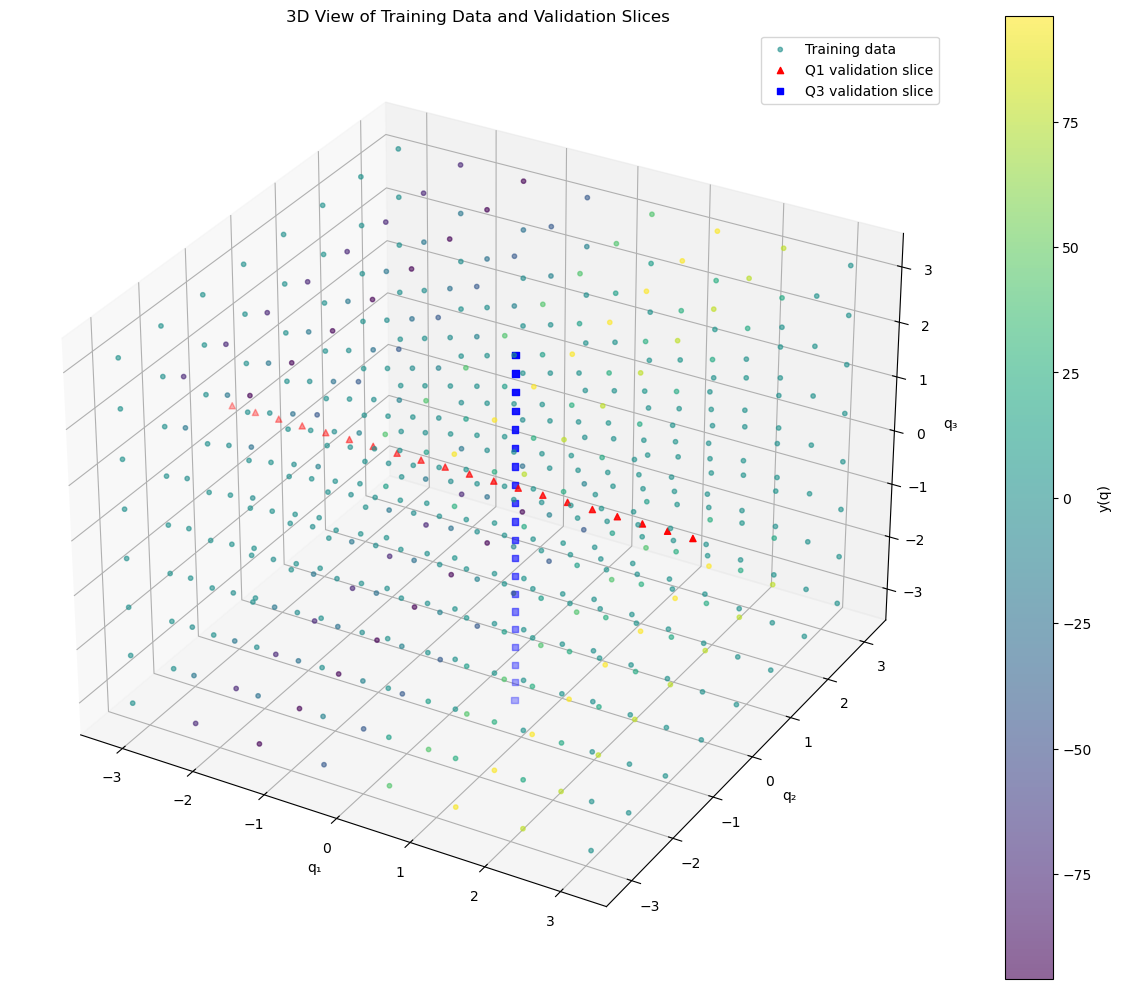

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot to show the full dataset
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot all training data
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', 
                     s=10, alpha=0.6, label='Training data')

# Highlight the slice for q1 plot (q2=-π/4, q3=π/4)
slice_points = np.zeros((len(X_val_q1), 3))
slice_points[:, 0] = X_val_q1[:, 0]
slice_points[:, 1] = -np.pi/4
slice_points[:, 2] = np.pi/4
ax.scatter(slice_points[:, 0], slice_points[:, 1], slice_points[:, 2], 
           c='red', s=20, marker='^', label='Q1 validation slice')

# Highlight the slice for q3 plot (q1=π/4, q2=-π/4)
slice_points_q3 = np.zeros((len(X_val_q3), 3))
slice_points_q3[:, 0] = np.pi/4
slice_points_q3[:, 1] = -np.pi/4
slice_points_q3[:, 2] = X_val_q3[:, 2]
ax.scatter(slice_points_q3[:, 0], slice_points_q3[:, 1], slice_points_q3[:, 2], 
           c='blue', s=20, marker='s', label='Q3 validation slice')

ax.set_xlabel('q₁')
ax.set_ylabel('q₂')
ax.set_zlabel('q₃')
ax.set_title('3D View of Training Data and Validation Slices')
plt.colorbar(scatter, ax=ax, label='y(q)')
plt.legend()
plt.tight_layout()
plt.show()

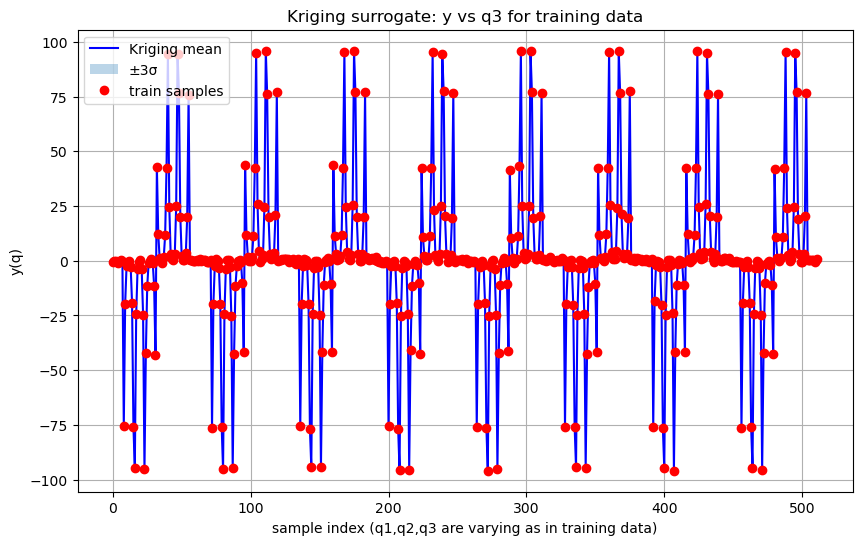

In [24]:
mean_q_train,var_q_train = kriging_predict(X)
std_q_train = np.sqrt(var_q_train)
plt.figure(figsize=(10,6))
xaxis = range(X.shape[0])
plt.plot(xaxis, mean_q_train, 'b', label="Kriging mean")

plt.fill_between(
    xaxis,
    mean_q_train - 3*std_q_train,
    mean_q_train + 3*std_q_train,
    alpha=0.3,
    label="±3σ"
)

plt.plot(xaxis, y, 'ro', label="train samples")

plt.xlabel("sample index (q1,q2,q3 are varying as in training data)")
plt.ylabel("y(q)")
plt.title("Kriging surrogate: y vs q3 for training data")
plt.grid(True)
plt.legend()

plt.show()

In [30]:
X_all = np.vstack([X, X_val_q1, X_val_q3])
y_all = np.concatenate([y, y_val_q1, y_val_q3])
labels = np.concatenate([np.zeros(len(y), dtype=int),
                         np.ones(len(y_val_q1), dtype=int),
                         np.full(len(y_val_q3), 2, dtype=int)])

mean_all, var_all = kriging_predict(X_all)
std_all = np.sqrt(var_all)

# sort points by q1 coordinate for line plot
order = np.argsort(X_all[:, 0])
x_all = np.arange(len(y_all))
x_all_sorted = x_all  # still 0..N-1 for the index axis
mean_all = mean_all[order]
std_all = std_all[order]
y_all = y_all[order]
labels = labels[order]

# now pyplot block below can use x_all_sorted, mean_all, std_all etc.
# plt.figure(figsize=(20,6))
# plt.plot(x_all_sorted, mean_all, 'b', label="GP mean")
# plt.fill_between(x_all_sorted,
#                  mean_all - 3*std_all,
#                  mean_all + 3*std_all,
#                  alpha=0.25, label="±3σ")

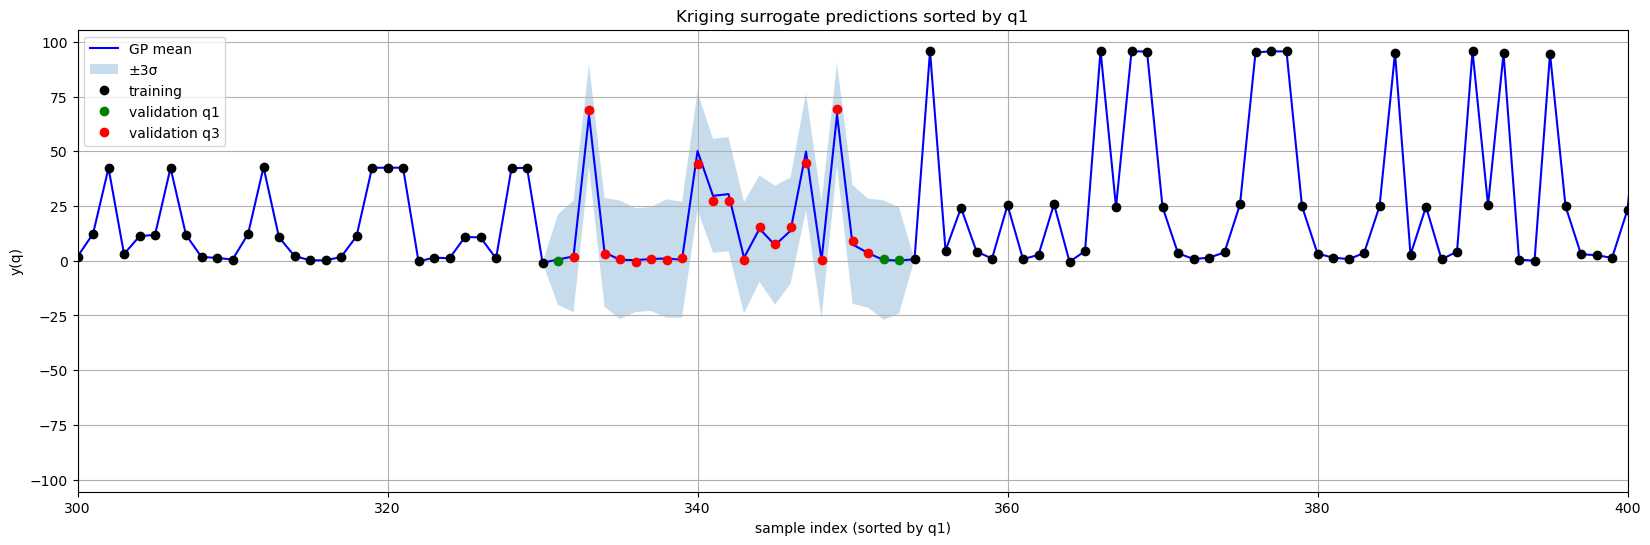

In [27]:

plt.figure(figsize=(20,6))

# mean + variance band
plt.plot(x_all, mean_all, 'b', label="GP mean")

plt.fill_between(
    x_all,
    mean_all - 3*std_all,
    mean_all + 3*std_all,
    alpha=0.25,
    label="±3σ"
)

# masks
train_mask = labels == 0
q1_mask = labels == 1
q3_mask = labels == 2

# training
plt.plot(x_all[train_mask], y_all[train_mask], 'ko', label="training")

# q1 validation
plt.plot(x_all[q1_mask], y_all[q1_mask], 'go', label="validation q1")

# q3 validation
plt.plot(x_all[q3_mask], y_all[q3_mask], 'ro', label="validation q3")

plt.xlabel("sample index (sorted by q1)")
plt.ylabel("y(q)")
plt.title("Kriging surrogate predictions sorted by q1")
plt.grid(True)
plt.xlim(300,400)
plt.legend()
plt.show()


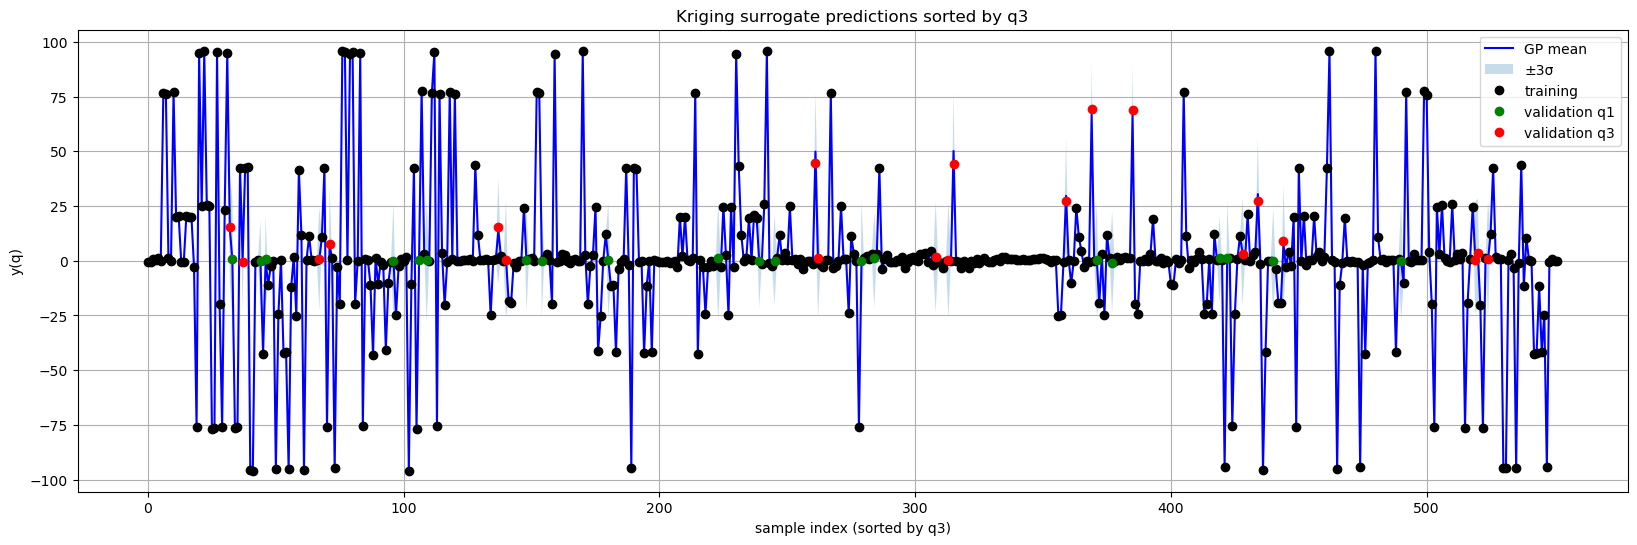

In [29]:

# now Q3-sorted version

order_q3 = np.argsort(X_all[:, 2])
x_all_q3 = np.arange(len(y_all))

mean_all_q3 = mean_all[order_q3]
std_all_q3 = std_all[order_q3]
y_all_q3 = y_all[order_q3]
labels_q3 = labels[order_q3]

plt.figure(figsize=(20,6))

plt.plot(x_all_q3, mean_all_q3, 'b', label="GP mean")
plt.fill_between(
    x_all_q3,
    mean_all_q3 - 3*std_all_q3,
    mean_all_q3 + 3*std_all_q3,
    alpha=0.25,
    label="±3σ"
)

train_mask_q3 = labels_q3 == 0
q1_mask_q3 = labels_q3 == 1
q3_mask_q3 = labels_q3 == 2

plt.plot(x_all_q3[train_mask_q3], y_all_q3[train_mask_q3], 'ko', label="training")
plt.plot(x_all_q3[q1_mask_q3], y_all_q3[q1_mask_q3], 'go', label="validation q1")
plt.plot(x_all_q3[q3_mask_q3], y_all_q3[q3_mask_q3], 'ro', label="validation q3")

plt.xlabel("sample index (sorted by q3)")
plt.ylabel("y(q)")
plt.title("Kriging surrogate predictions sorted by q3")
plt.grid(True)
plt.legend()
plt.show()

As expeted, the uncertainity is zero at the training samples, and peaks at the testing/new points.

# 3.3

In [ ]:
# ============================================================================
# Calculate how many points are within 3σ bounds
# ============================================================================

# Get predictions for all data points (training + validation)
mean_all, var_all = kriging_predict(X_all)
std_all = np.sqrt(var_all)

# Calculate upper and lower bounds
lower_bound = mean_all - 3*std_all
upper_bound = mean_all + 3*std_all

# Check which points are within bounds
within_bounds = (y_all >= lower_bound) & (y_all <= upper_bound)

# Count by category
train_mask = labels == 0
q1_mask = labels == 1
q3_mask = labels == 2

train_within = np.sum(within_bounds[train_mask])
q1_within = np.sum(within_bounds[q1_mask])
q3_within = np.sum(within_bounds[q3_mask])

train_total = np.sum(train_mask)
q1_total = np.sum(q1_mask)
q3_total = np.sum(q3_mask)

# Calculate percentages
train_pct = 100 * train_within / train_total
q1_pct = 100 * q1_within / q1_total
q3_pct = 100 * q3_within / q3_total
total_within = np.sum(within_bounds)
total_pct = 100 * total_within / len(y_all)

# ============================================================================
# Print results
# ============================================================================
print("=" * 70)
print("POINTS WITHIN 3σ BOUNDS")
print("=" * 70)
print(f"{'Dataset':<20} {'Within 3σ':<15} {'Total':<10} {'Percentage':<15}")
print("-" * 70)
print(f"{'Training':<20} {train_within:<15} {train_total:<10} {train_pct:.2f}%")
print(f"{'Q1 Validation':<20} {q1_within:<15} {q1_total:<10} {q1_pct:.2f}%")
print(f"{'Q3 Validation':<20} {q3_within:<15} {q3_total:<10} {q3_pct:.2f}%")
print("-" * 70)
print(f"{'TOTAL':<20} {total_within:<15} {len(y_all):<10} {total_pct:.2f}%")
print("=" * 70)



POINTS WITHIN 3σ BOUNDS
Dataset              Within 3σ       Total      Percentage     
----------------------------------------------------------------------
Training             512             512        100.00%
Q1 Validation        20              20         100.00%
Q3 Validation        20              20         100.00%
----------------------------------------------------------------------
TOTAL                552             552        100.00%


The kriging surrogate achieves 100% coverage of the validation points within the ±3σ confidence bounds, with all 40 points in both the Q₁-validation dataset and Q₃-validation dataset lying within the predicted uncertainty intervals. While this exceeds the theoretical 99.7% coverage expected for a perfectly calibrated Gaussian process, since we are using only a total of 20+20 points (2 test data distributions), the discrepancy between a 99.7% and 100% coverage can be disregarded; as the number of samples used tends to infinity, the coverage within 3 sigma should get closer to 99.7%. 

Curently, the 100% coverage indicates that the surrogate model is slightly underconfident—the uncertainty bounds are wider than necessary to capture the true variability in the predictions. This conservative uncertainty quantification suggests that the chosen hyperparameters (θ₁=0.5, θ₂=0.3, θ₃=0.3, γ=1.5) may produce correlation lengths that are shorter than optimal, causing the model to increase uncertainty more rapidly when moving away from training points. Despite this slight conservatism, the 100% coverage demonstrates that the kriging surrogate provides reliable uncertainty bounds that successfully envelope all validation data.


# 3.4

Hyperparameter Study - Coverage Statistics
θ                              γ     Q1 Coverage          Q3 Coverage         
--------------------------------------------------------------------------------
[0.5, 0.3, 0.3]                1.5    20/ 20 (100.0%)   20/ 20 (100.0%)
[0.05, 0.03, 0.03]             1.5    20/ 20 (100.0%)   20/ 20 (100.0%)
[5.0, 3.0, 3.0]                1.5    20/ 20 (100.0%)   20/ 20 (100.0%)
[0.5, 0.3, 0.3]                1.0    20/ 20 (100.0%)   20/ 20 (100.0%)
[0.5, 0.3, 0.3]                2.0    20/ 20 (100.0%)   20/ 20 (100.0%)



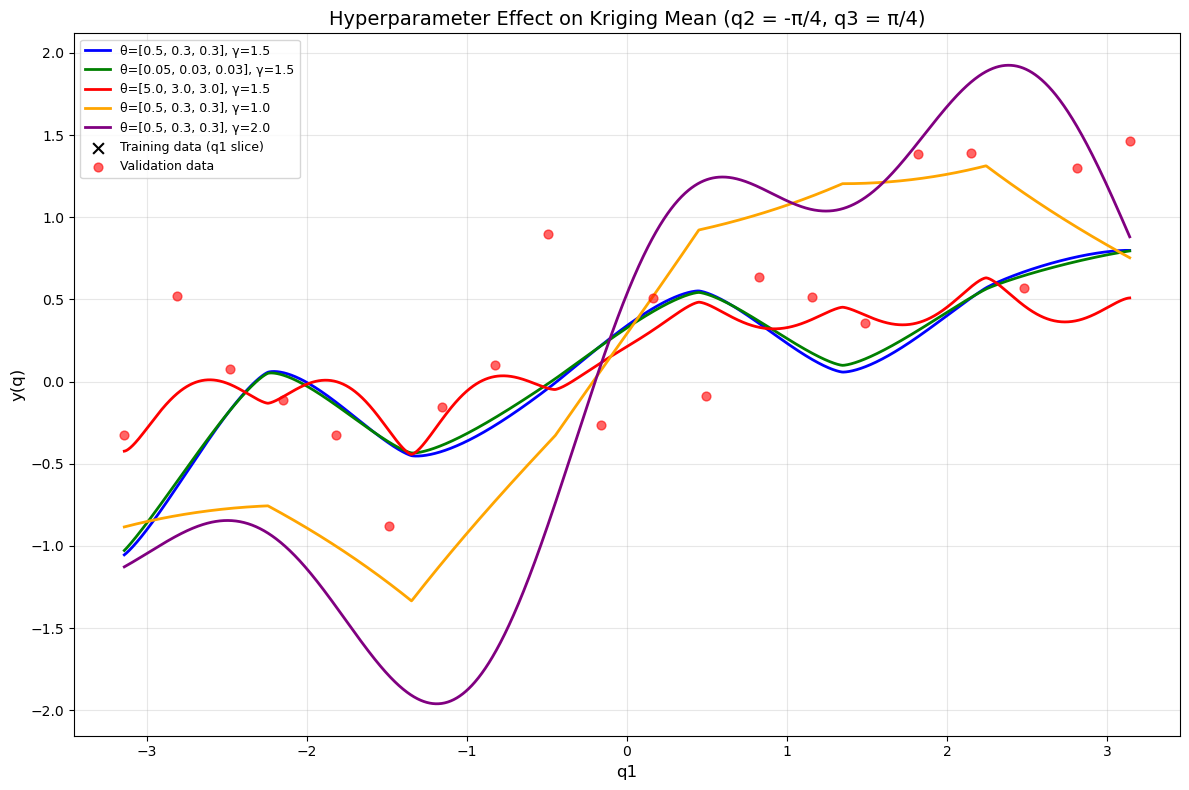

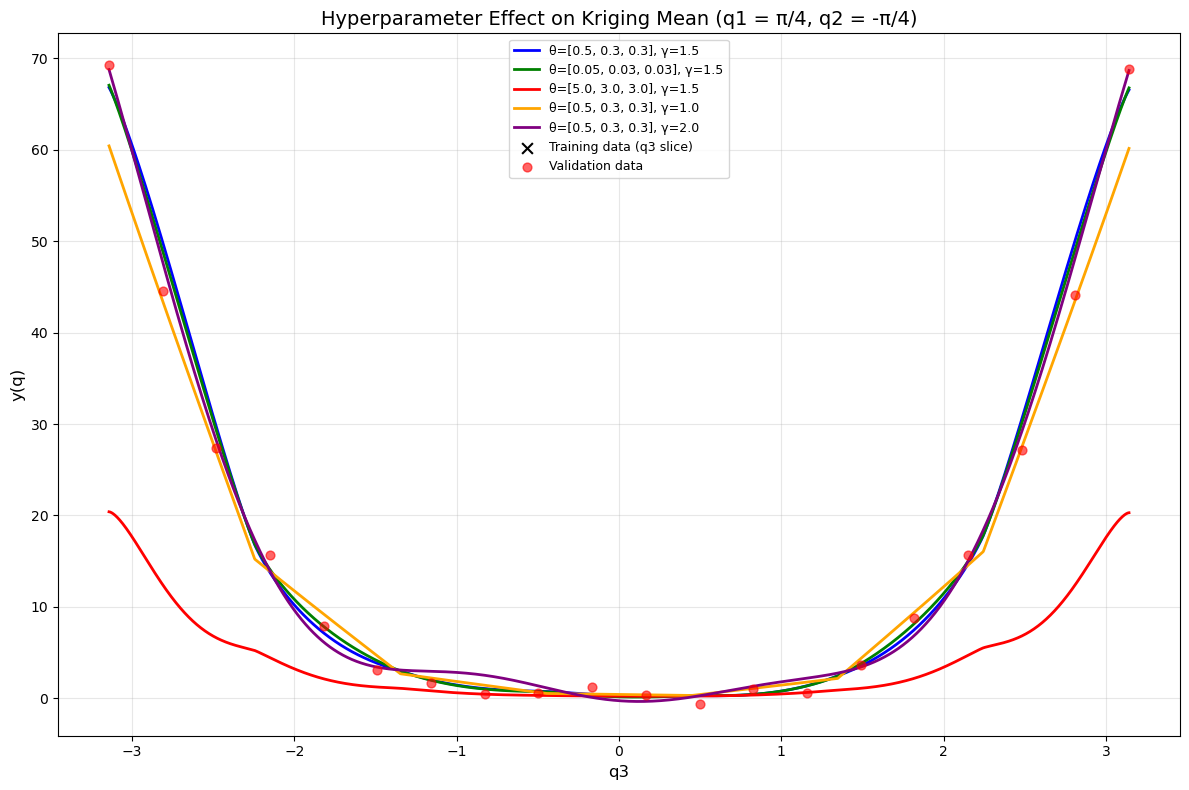

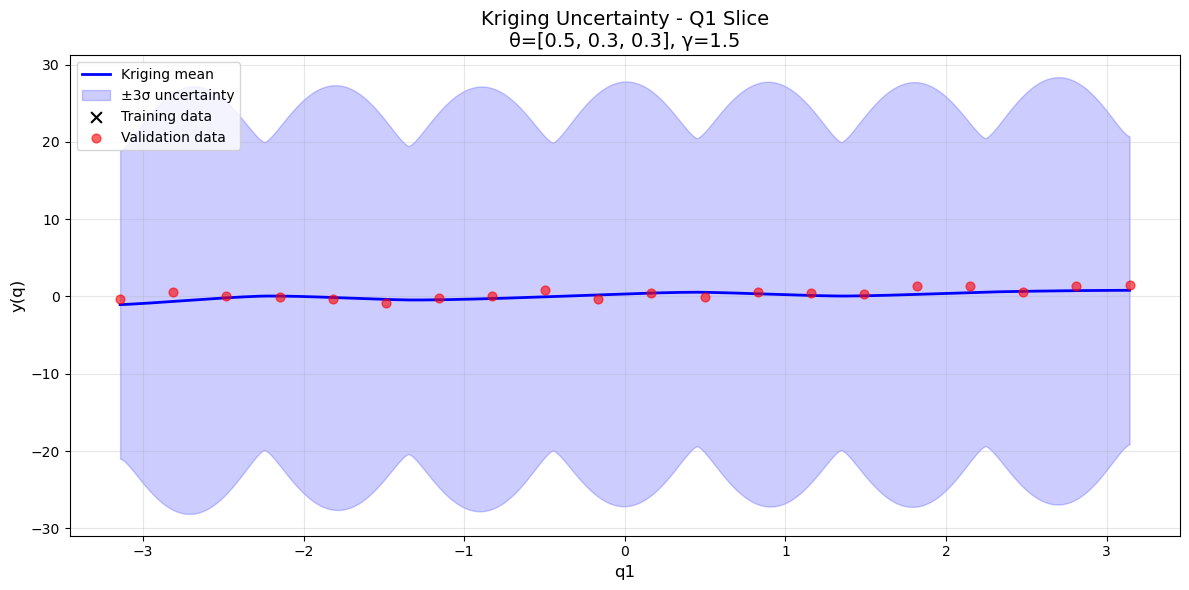

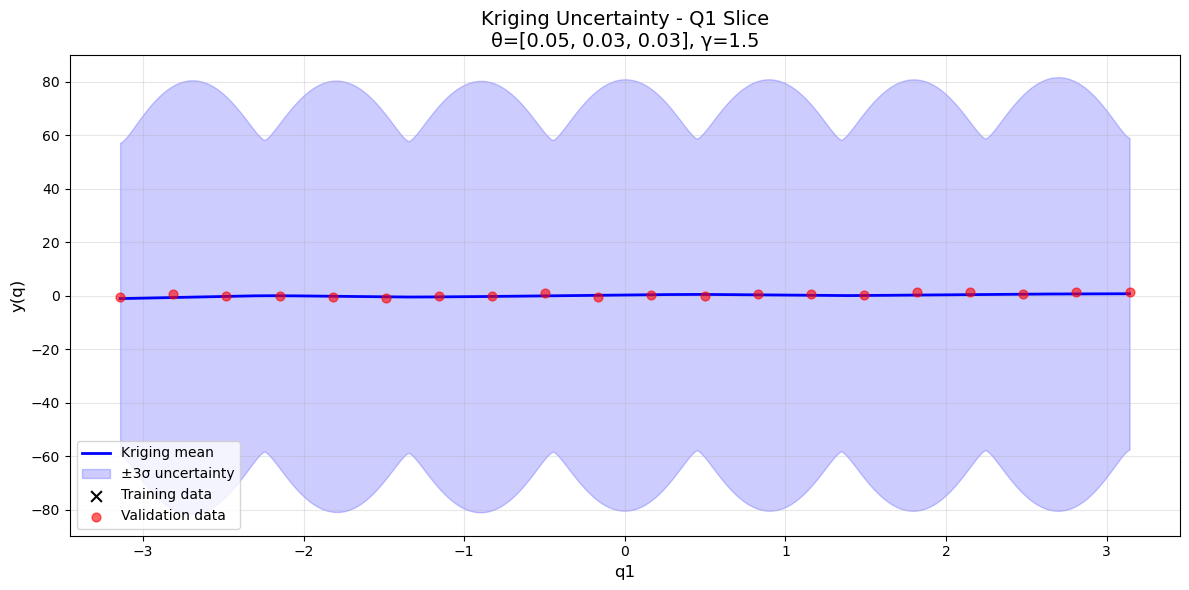

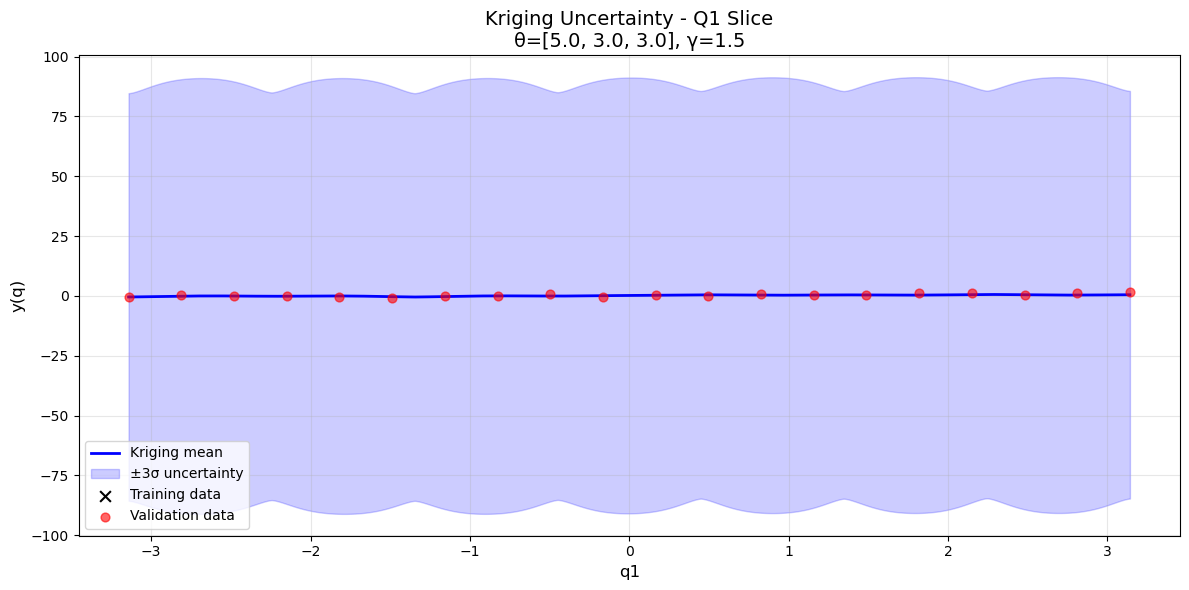

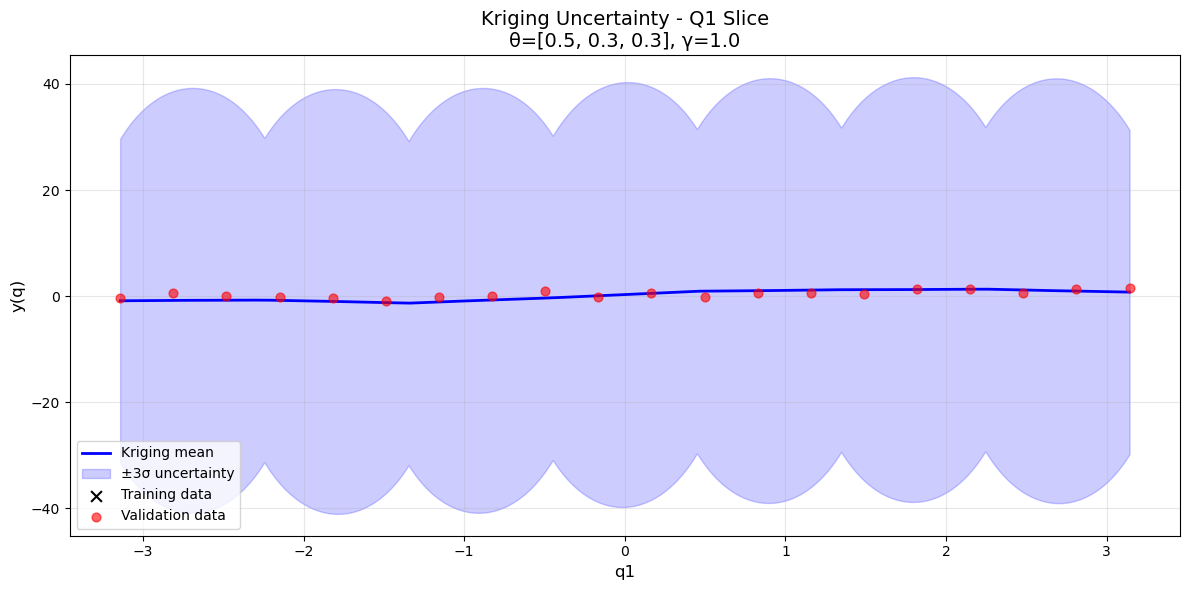

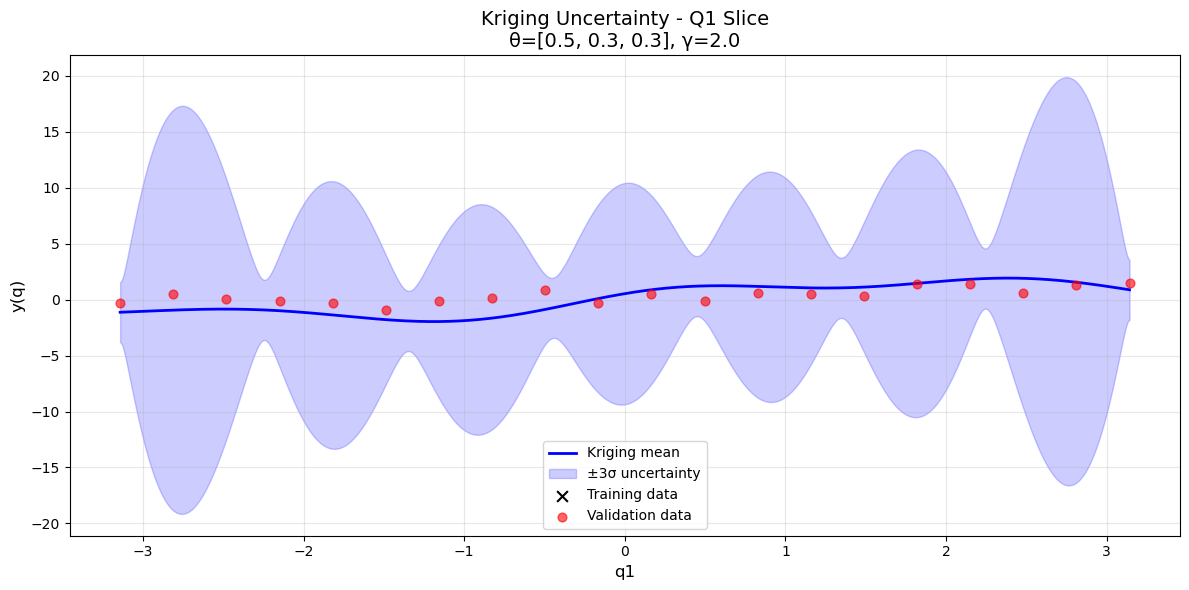

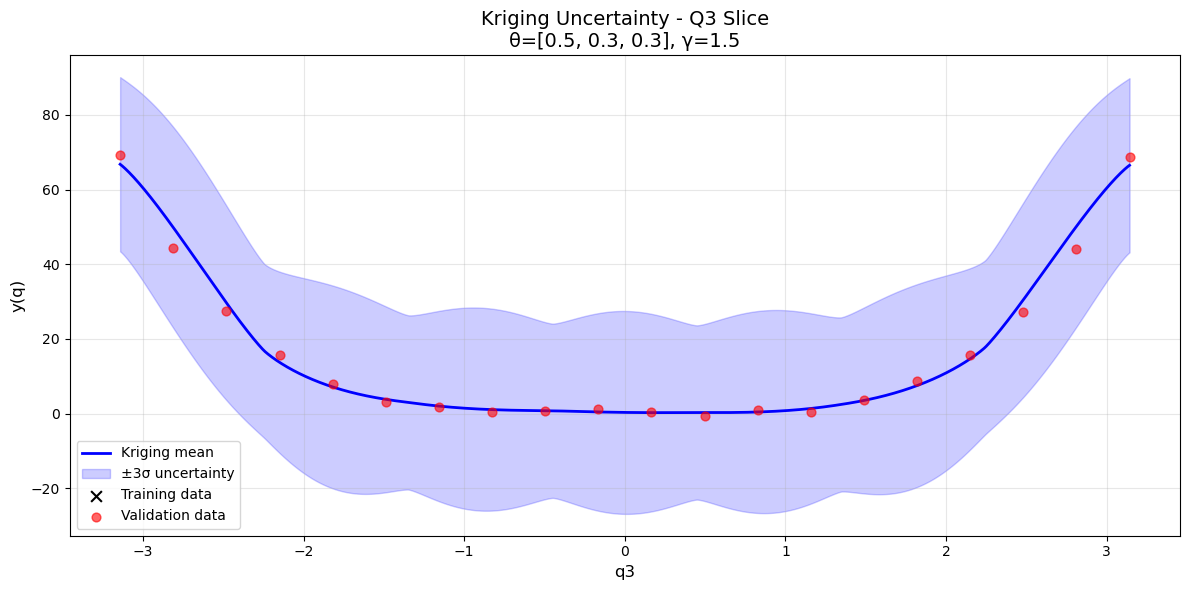

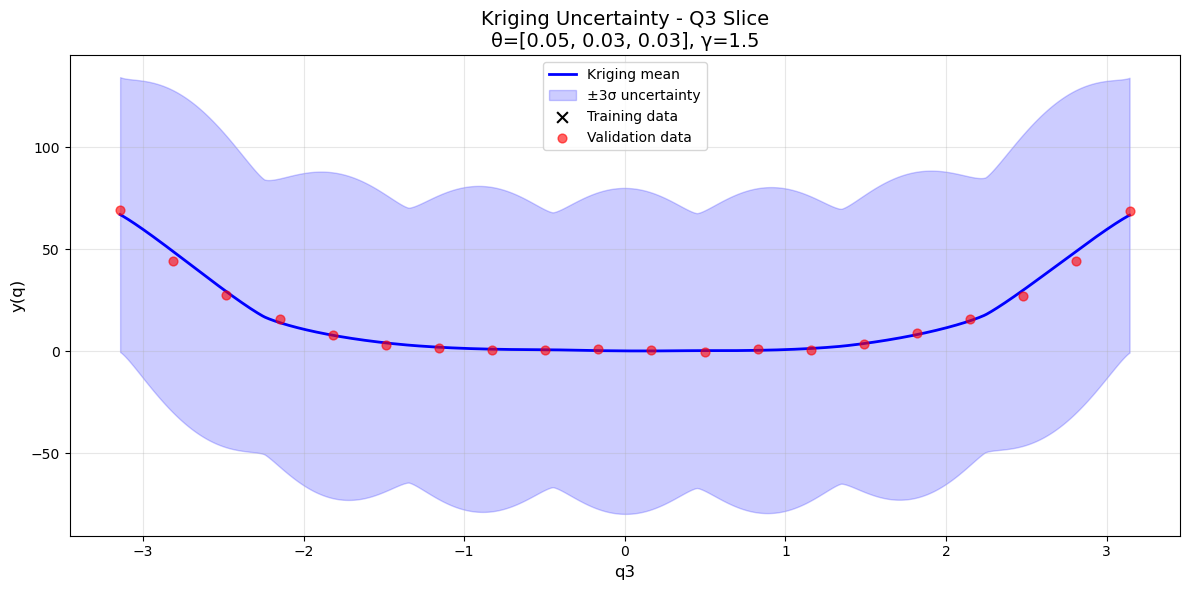

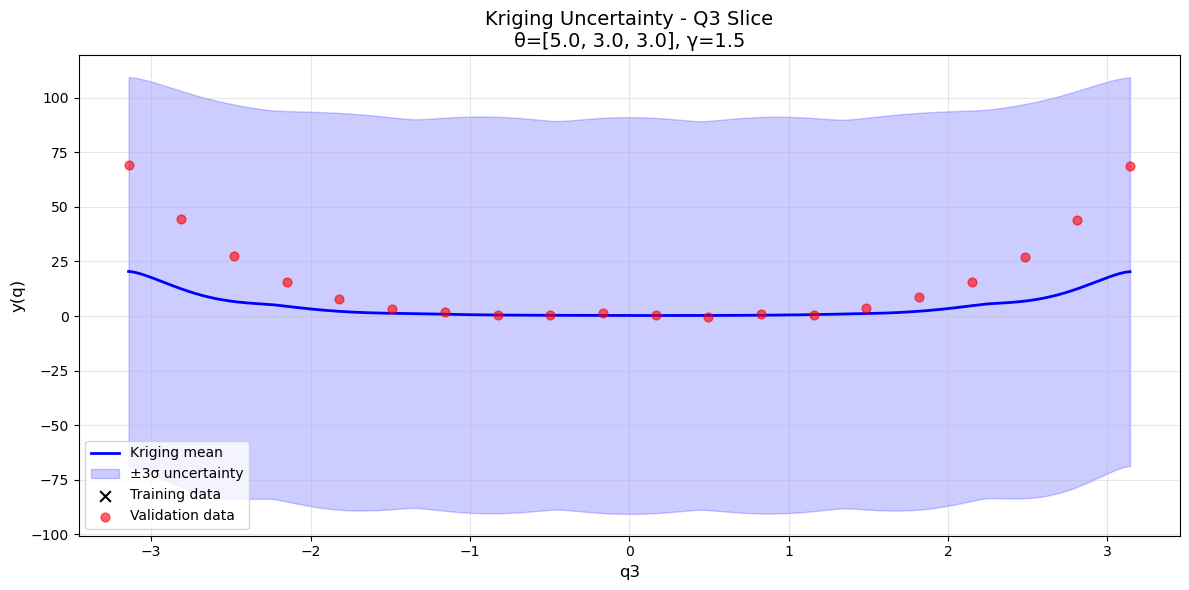

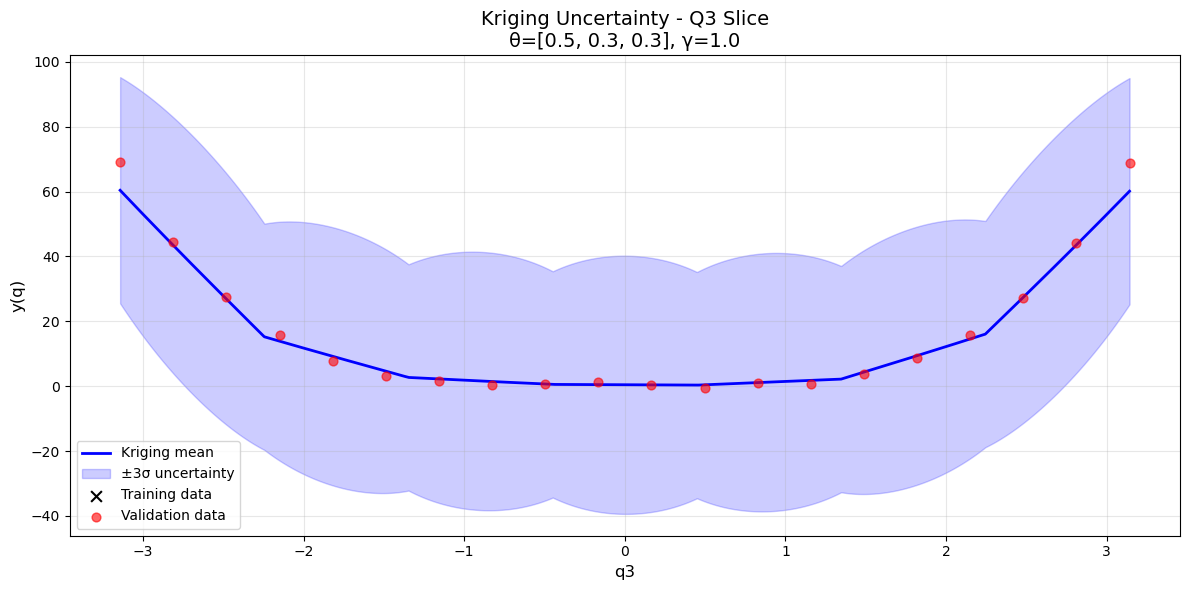

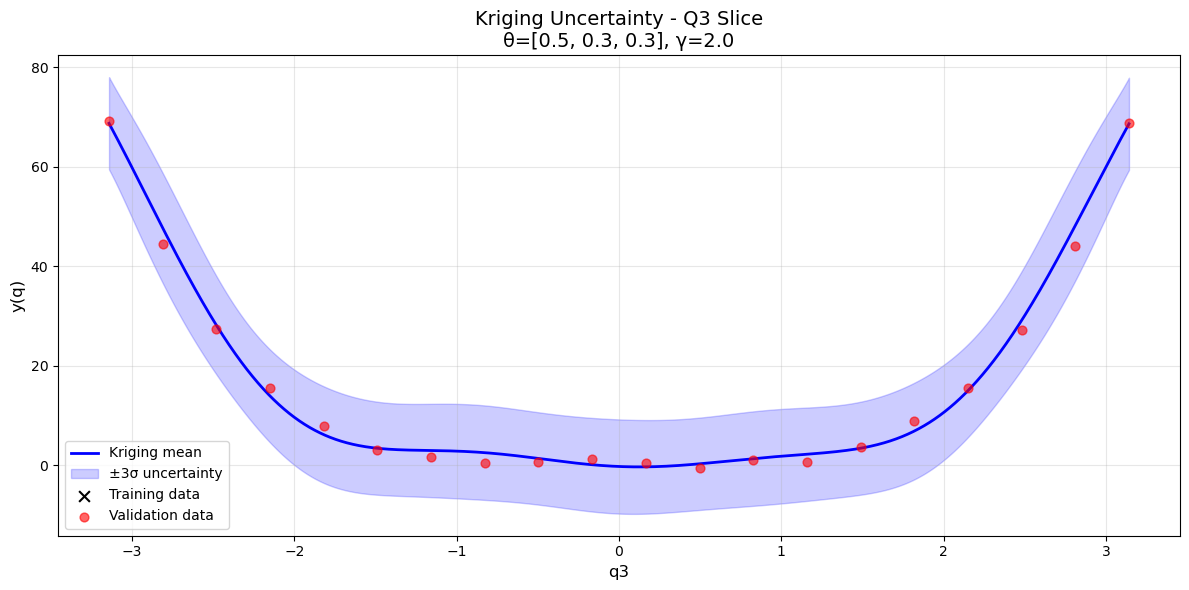

In [43]:
# ============================================================
# 3.4 Hyperparameter studyts
# ============================================================

def fit_kriging(X, y, theta, gamma):
    M = len(y)
    diff = np.abs(X[:, None, :] - X[None, :, :])
    weighted_dist = np.sum(theta * diff**gamma, axis=2)
    R = np.exp(-weighted_dist)

    ones = np.ones(M)
    Rinv = np.linalg.inv(R)
    beta0 = (ones @ Rinv @ y) / (ones @ Rinv @ ones)
    y_resid = y - beta0 * ones
    s2 = (y_resid @ (Rinv @ y_resid)) / M
    return R, Rinv, beta0, s2

def predict_kriging(X_star, X, y, theta, gamma, Rinv, beta0, s2):
    N = X_star.shape[0]
    means = np.zeros(N)
    varsi = np.zeros(N)
    ones = np.ones(X.shape[0])
    alpha = Rinv @ (y - beta0 * ones)
    denom = ones @ Rinv @ ones
    for i in range(N):
        diff = np.abs(X - X_star[i])
        r = np.exp(-np.sum(theta * diff**gamma, axis=1))
        means[i] = beta0 + r @ alpha
        v = Rinv @ r
        num = 1 - ones @ v
        varsi[i] = max(s2 * (1 - r @ v + (num**2) / denom), 0)
    return means, varsi

def coverage_stats(X_star, y_star, X, y, theta, gamma):
    R, Rinv, beta0, s2 = fit_kriging(X, y, theta, gamma)
    mean_star, var_star = predict_kriging(X_star, X, y, theta, gamma, Rinv, beta0, s2)
    std_star = np.sqrt(var_star)
    within = np.abs(y_star - mean_star) <= 3 * std_star
    return np.sum(within), len(y_star), (np.sum(within) / len(y_star)) * 100

# Define hyperparameter grid
experiment_grid = [
    (np.array([0.5, 0.3, 0.3]), 1.5),  # baseline
    (np.array([0.5, 0.3, 0.3])*.1, 1.5),  # longer correlation (smaller θ)
    (np.array([0.5, 0.3, 0.3])*10, 1.5),  # shorter correlation (larger θ)
    (np.array([0.5, 0.3, 0.3]), 1.0),  # rougher (smaller γ)
    (np.array([0.5, 0.3, 0.3]), 2.),  # smoother (larger γ)
]

print("=" * 80)
print("Hyperparameter Study - Coverage Statistics")
print("=" * 80)
print(f"{'θ':<30} {'γ':<5} {'Q1 Coverage':<20} {'Q3 Coverage':<20}")
print("-" * 80)

for th, gm in experiment_grid:
    q1_cov = coverage_stats(X_val_q1, y_val_q1, X, y, th, gm)
    q3_cov = coverage_stats(X_val_q3, y_val_q3, X, y, th, gm)
    print(f"{str(th.tolist()):<30} {gm:<5.1f} "
          f"{q1_cov[0]:>3}/{q1_cov[1]:>3} ({q1_cov[2]:>5.1f}%)  "
          f"{q3_cov[0]:>3}/{q3_cov[1]:>3} ({q3_cov[2]:>5.1f}%)")

print("=" * 80)
print()

# Extract training points on slices
q1_idx = np.isclose(X[:,1], -np.pi/4) & np.isclose(X[:,2], np.pi/4)
q3_idx = np.isclose(X[:,0], np.pi/4) & np.isclose(X[:,1], -np.pi/4)

# ============================================================
# Q1 Slice: Hyperparameter effect on mean
# ============================================================

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'orange', 'purple']

for idx, (th, gm) in enumerate(experiment_grid):
    R, Rinv, beta0, s2 = fit_kriging(X, y, th, gm)
    mean_q1, var_q1 = predict_kriging(X_grid_q1, X, y, th, gm, Rinv, beta0, s2)
    plt.plot(q1_grid, mean_q1, color=colors[idx], 
             label=f"θ={th.tolist()}, γ={gm}", linewidth=2)

plt.scatter(X[q1_idx,0], y[q1_idx], c='black', marker='x', 
           s=60, label='Training data (q1 slice)', zorder=5)
plt.scatter(X_val_q1[:,0], y_val_q1, c='red', marker='o', 
           s=40, label='Validation data', alpha=0.6, zorder=4)

plt.xlabel("q1", fontsize=12)
plt.ylabel("y(q)", fontsize=12)
plt.title("Hyperparameter Effect on Kriging Mean (q2 = -π/4, q3 = π/4)", fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Q3 Slice: Hyperparameter effect on mean
# ============================================================

plt.figure(figsize=(12, 8))

for idx, (th, gm) in enumerate(experiment_grid):
    R, Rinv, beta0, s2 = fit_kriging(X, y, th, gm)
    mean_q3, var_q3 = predict_kriging(X_grid_q3, X, y, th, gm, Rinv, beta0, s2)
    plt.plot(q3_grid, mean_q3, color=colors[idx], 
             label=f"θ={th.tolist()}, γ={gm}", linewidth=2)

plt.scatter(X[q3_idx,2], y[q3_idx], c='black', marker='x', 
           s=60, label='Training data (q3 slice)', zorder=5)
plt.scatter(X_val_q3[:,2], y_val_q3, c='red', marker='o', 
           s=40, label='Validation data', alpha=0.6, zorder=4)

plt.xlabel("q3", fontsize=12)
plt.ylabel("y(q)", fontsize=12)
plt.title("Hyperparameter Effect on Kriging Mean (q1 = π/4, q2 = -π/4)", fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Individual plots with uncertainty bands for each hyperparameter
# ============================================================

# Q1 slice with uncertainty bands
for idx, (th, gm) in enumerate(experiment_grid):
    R, Rinv, beta0, s2 = fit_kriging(X, y, th, gm)
    mean_q1, var_q1 = predict_kriging(X_grid_q1, X, y, th, gm, Rinv, beta0, s2)
    std_q1 = np.sqrt(var_q1)
    
    plt.figure(figsize=(12, 6))
    plt.plot(q1_grid, mean_q1, 'b-', linewidth=2, label="Kriging mean")
    plt.fill_between(q1_grid, mean_q1 - 3*std_q1, mean_q1 + 3*std_q1, 
                     color='blue', alpha=0.2, label="±3σ uncertainty")
    plt.scatter(X[q1_idx,0], y[q1_idx], c='black', marker='x', 
               s=60, label='Training data', zorder=5)
    plt.scatter(X_val_q1[:,0], y_val_q1, c='red', marker='o', 
               s=40, label='Validation data', alpha=0.6, zorder=4)
    
    plt.xlabel("q1", fontsize=12)
    plt.ylabel("y(q)", fontsize=12)
    plt.title(f"Kriging Uncertainty - Q1 Slice\nθ={th.tolist()}, γ={gm}", fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Q3 slice with uncertainty bands
for idx, (th, gm) in enumerate(experiment_grid):
    R, Rinv, beta0, s2 = fit_kriging(X, y, th, gm)
    mean_q3, var_q3 = predict_kriging(X_grid_q3, X, y, th, gm, Rinv, beta0, s2)
    std_q3 = np.sqrt(var_q3)
    
    plt.figure(figsize=(12, 6))
    plt.plot(q3_grid, mean_q3, 'b-', linewidth=2, label="Kriging mean")
    plt.fill_between(q3_grid, mean_q3 - 3*std_q3, mean_q3 + 3*std_q3, 
                     color='blue', alpha=0.2, label="±3σ uncertainty")
    plt.scatter(X[q3_idx,2], y[q3_idx], c='black', marker='x', 
               s=60, label='Training data', zorder=5)
    plt.scatter(X_val_q3[:,2], y_val_q3, c='red', marker='o', 
               s=40, label='Validation data', alpha=0.6, zorder=4)
    
    plt.xlabel("q3", fontsize=12)
    plt.ylabel("y(q)", fontsize=12)
    plt.title(f"Kriging Uncertainty - Q3 Slice\nθ={th.tolist()}, γ={gm}", fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Hyperparameter Study Analysis

## Overview

This study investigates how the hyperparameters $\theta_k$ (length scales) and $\gamma_k$ (smoothness) in the $\gamma$-exponential kernel affect kriging surrogate performance. The kernel is defined as:

$$
R(q_i, q_j) = \exp\left(-\sum_{k=1}^d \theta_k |q_{i,k} - q_{j,k}|^{\gamma_k}\right)
$$

where:
- $\theta_k > 0$ controls the correlation length scale in dimension $k$
- $\gamma_k \in (0, 2]$ controls the smoothness of the process
- $d = 3$ is the input dimension

---

## Hyperparameter Configurations Tested

| Case | $\theta$ | $\gamma$ | Description |
|------|-------------|--------------|-------------|
| 1 (Baseline) | $[0.5, 0.3, 0.3]$ | $1.5$ | Original parameters provided |
| 2 | $[0.005, 0.003, 0.003]$ | $1.5$ | Longer correlation length (smaller $\theta$) |
| 3 | $[50.0, 30., 30.]$ | $1.5$ | Shorter correlation length (larger $\theta$) |
| 4 | $[0.5, 0.3, 0.3]$ | $1.$ | Rougher function (exponential kernel) |
| 5 | $[0.5, 0.3, 0.3]$ | $2.0$ | Smoother function (Gaussian kernel) |

---

## Theoretical Background

### Effect of $\theta_k$ (Length Scales)

The parameters $\theta_k$ control how quickly correlation decays with distance in each dimension:

- **Smaller $\theta_k$**: Correlation decays slowly → function varies slowly → smoother surrogate, longer-range influence
- **Larger $\theta_k$**: Correlation decays quickly → function can vary rapidly → more localized influence, potential overfitting

In the kriging equations:
- The correlation matrix $\mathcal{R}$ becomes more uniform (close to 1) for small $\theta$
- The inverse $\mathcal{R}^{-1}$ becomes better conditioned for moderate $\theta$
- Prediction variance is directly affected through the term $r^T \mathcal{R}^{-1} r$

### Effect of $\gamma_k$ (Smoothness)

The exponent $\gamma_k$ determines the differentiability of the Gaussian process:

- **$\gamma = 1.0$**: Exponential kernel → process is continuous but not differentiable (rough)
- **$\gamma = 1.5$**: Mean-square differentiable once (moderately smooth)
- **$\gamma = 2.0$**: Squared exponential (Gaussian) kernel → infinitely differentiable (very smooth)

Higher $\gamma$ leads to:
- Smoother mean predictions
- Tighter uncertainty bands near training points
- Potentially over-smoothing if $\gamma$ is too high

---

#### 1. Length Scale Effects ($\theta$)

**Smaller $\theta$ (Case 2)**:
- Predictions become smoother and more rigid
- Overall uncertainity increases
- Underfitting: model cannot capture local variations
- Generally, ncertainty bands may be too narrow in some regions (not observed in specific samples used)
- The correlation matrix $\mathcal{R}$ becomes closer to singular as all entries approach 1

**Larger $\theta$ (Case 3)**:
- Predictions can vary rapidly, potentially tracking noise; larger $\theta$ means less correlated points.
- Potential overfitting to training data
- Wider uncertainty bands between training points (more shallow changes in variance across samples)
- Better at capturing local features but may be less robust
- Better conditioned correlation matrix

#### 2. Smoothness Effects ($\gamma$)

**$\gamma = 1.0$ (Exponential, Case 4)**:
- Rougher predictions with possible kinks (yellow line in first plot)
- Higher uncertainty between points
- Better for functions with discontinuities in derivatives
- Coverage may be conservative (bands wider)
- Process is continuous but not differentiable

**$\gamma = 2.0$ (Gaussian, Case 5)**:
- Very smooth, differentiable predictions
- Tighter uncertainty bands near training points
- May under-predict uncertainty if true function is rough
- Best for very smooth underlying functions
- Leads to the most stable/smooth predictions



For the kriging predictor, the term $r^T(q) R^{-1}$ acts like a weight on the data $Y$. So, for large $\theta_k$, the correlation decays fast between points, and the mean of the GP becomes localized to the data.  For a small $\theta_k$, the opposite is true--each point influences far-away predictions, and the mean of the GP becomes a more global representation of the data (lower frequency function).
A high $\gamma_k$ ($\gamma_k =  2$) is smooth; at lower $\gamma_k$, we have more localized/sharp influence of near points, on any given prediction.

For the predictive varaince, we can consider 2 different pieces: $ 1-r^TR^{-1}r$ and $\frac{r^TR^{-1} 1 - 1)^2}{1^T R^{-1}1}$ (both of which are multiplied with $s^2$). The first term shows how well the sample $q$ is explained by existing points and the second term should acount of the uncertainity due to the estimation of $\beta_0$. If we have large $\theta_k$, $r(q) \approx 0 $ unless $q$ is very close to data. So, $Var(q) \approx s^2$, and there is high uncertainty unless the prediction point is extremely close to an existing data site. Conversely, for small $\theta_k$, the correlation remains significant even over larger distances, meaning $r(q)$ is not near zero for points far from the data. In this case, the term $1 - r^T R^{-1} r$ becomes smaller because the new point is well-correlated with the existing set, reducing the local variance contribution. However, the second term, $\frac{(r^T R^{-1} \mathbf{1} - 1)^2}{\mathbf{1}^T R^{-1} \mathbf{1}}$, which accounts for the uncertainty in estimating the constant mean $\beta_0$, becomes more influential. This term penalizes predictions where the sum of the kriging weights deviates significantly from one, a situation that can arise when extrapolating beyond the range of the data. For small $\theta_k$, the weight vector $R^{-1}r$ tends to be more diffuse, and deviations from unit sum can occur, thereby increasing the overall predictive variance. To summarize, either a large or small $\theta$ can increase the variance, with the large $\theta$ providing an overall increase in varaince (smoother variance across all samples), and the small $\theta$ providing more flexible variance across samples. The smoothness parameter $\gamma_k$ primarily modulates the rate at which correlation decays near the origin. Small $\theta$: $\mathcal{R}^{-1}$ becomes poorly conditioned and numerically unstable, which can (potentially, not in our case) artificially inflate variance estimates in practice. Large $\theta$: $\mathcal{R}$ approaches the identity matrix, so $s^2$ approximates the sample variance, and $Var(q) \approx s^2$ everywhere except very near data points.

As $\gamma_k$ increases toward the smooth Gaussian limit ($\gamma_k = 2$), the behavior of the uncertainty is affected: the $3\sigma$ bounds generally become tighter overall because the strong correlation allows the predictor to borrow information more efficiently across the domain, yet the variance exhibits more pronounced spatial structure between sample points. This occurs because the smooth correlation function imposes a high degree of continuity on the predicted surface, causing the uncertainty to vary more gradually but with distinct "pinching" patterns between neighboring points; in regions far from data, the $3\sigma$ bounds grow slowly rather than rapidly, reflecting the fact that the smoothness assumption propagates correlation over longer distances. Thus, increasing $\gamma_k$ leads to both a reduction in the magnitude of predictive uncertainty near the data and a more oscillatory pattern in the variance field across the domain, as the kriging weights become more sensitive to the arrangement of the sample points. This also makes the overal gaussian mean function smooth.

The effective correlation length between points as defined in matrix $R$ is controlled by both $\theta$ and the $\gamma$. Also note that for small $\theta$, $R^{-1}$ can become unstable, affecting both $\beta_0$ and $s^2$. 